# 03 Mining

Notebook nay chay association rules va customer clustering.

In [1]:
from pathlib import Path
import sys
from IPython.display import Image, display

PROJECT_ROOT = Path.cwd()
if not (PROJECT_ROOT / 'src').exists():
    PROJECT_ROOT = PROJECT_ROOT.parent
if str(PROJECT_ROOT) not in sys.path:
    sys.path.insert(0, str(PROJECT_ROOT))

from src.config import load_params
from src.data import load_raw_data, clean_sales_data
from src.features import build_basket_transactions, build_customer_features
from src.mining import mine_association_rules, run_customer_clustering

config = load_params()
raw_df = load_raw_data(config, PROJECT_ROOT)
clean_df, _ = clean_sales_data(raw_df, config)
transactions_df = build_basket_transactions(clean_df, item_level=config['preprocessing']['basket_item_level'])
itemsets_df, rules_df = mine_association_rules(transactions_df, config)
customer_features = build_customer_features(clean_df)
cluster_comparison_df, cluster_assignment_df, cluster_profile_df = run_customer_clustering(customer_features, config)


In [2]:
print('Top association rules')
display(rules_df.head(10))


Top association rules


,antecedent,consequent,antecedent_size,consequent_size,support,confidence,lift,algorithm,item_level
0,"Binders, Paper",Storage,2,1,0.010565,0.194757,1.254701,apriori,Sub-Category
1,Storage,"Binders, Paper",1,2,0.010565,0.068063,1.254701,apriori,Sub-Category
2,"Binders, Paper",Phones,2,1,0.010768,0.198502,1.216720,apriori,Sub-Category
3,Phones,"Binders, Paper",1,2,0.010768,0.066002,1.216720,apriori,Sub-Category
4,"Paper, Phones",Binders,2,1,0.010768,0.313609,1.195651,apriori,Sub-Category
5,Binders,"Paper, Phones",1,2,0.010768,0.041053,1.195651,apriori,Sub-Category
6,"Binders, Phones",Paper,2,1,0.010768,0.271795,1.150279,apriori,Sub-Category
7,Paper,"Binders, Phones",1,2,0.010768,0.045572,1.150279,apriori,Sub-Category
8,"Paper, Storage",Binders,2,1,0.010565,0.298851,1.139382,apriori,Sub-Category
9,Binders,"Paper, Storage",1,2,0.010565,0.040279,1.139382,apriori,Sub-Category


In [3]:
print('Clustering comparison')
display(cluster_comparison_df.head())
print('Cluster profile')
display(cluster_profile_df.head())


Clustering comparison


,algorithm,k,eps,min_samples,silhouette,davies_bouldin,min_cluster_share,max_cluster_share,noise_share,accepted_for_report,feature_count,features
0,kmeans,4,NaN,NaN,0.389521,1.011043,0.081967,0.614124,0.0,True,5,"recency_days, total_sales, avg_order_value, ac..."
1,kmeans,3,NaN,NaN,0.354054,1.169021,0.150063,0.655738,0.0,True,5,"recency_days, total_sales, avg_order_value, ac..."
2,kmeans,2,NaN,NaN,0.341247,1.428355,0.302648,0.697352,0.0,True,5,"recency_days, total_sales, avg_order_value, ac..."
3,agglomerative,4,NaN,NaN,0.315016,1.143918,0.060530,0.538462,0.0,True,5,"recency_days, total_sales, avg_order_value, ac..."
4,agglomerative,3,NaN,NaN,0.284043,1.308295,0.220681,0.538462,0.0,True,5,"recency_days, total_sales, avg_order_value, ac..."


Cluster profile


,cluster,customer_count,avg_sales,avg_order_value,recency_days,order_count,unique_categories,unique_subcategories,active_days,active_months,sales_per_active_month
0,0,487,2741.321,404.364,83.146,6.945,3.000,8.314,1089.376,6.396,437.641
1,2,135,1339.311,259.031,106.533,4.889,1.896,5.296,995.044,4.622,275.061
2,3,106,1369.076,372.255,514.472,3.774,2.519,5.462,506.142,3.519,402.592
3,1,65,9239.757,1432.119,138.092,7.385,2.954,9.215,1063.462,6.631,1545.487



Association sales overview


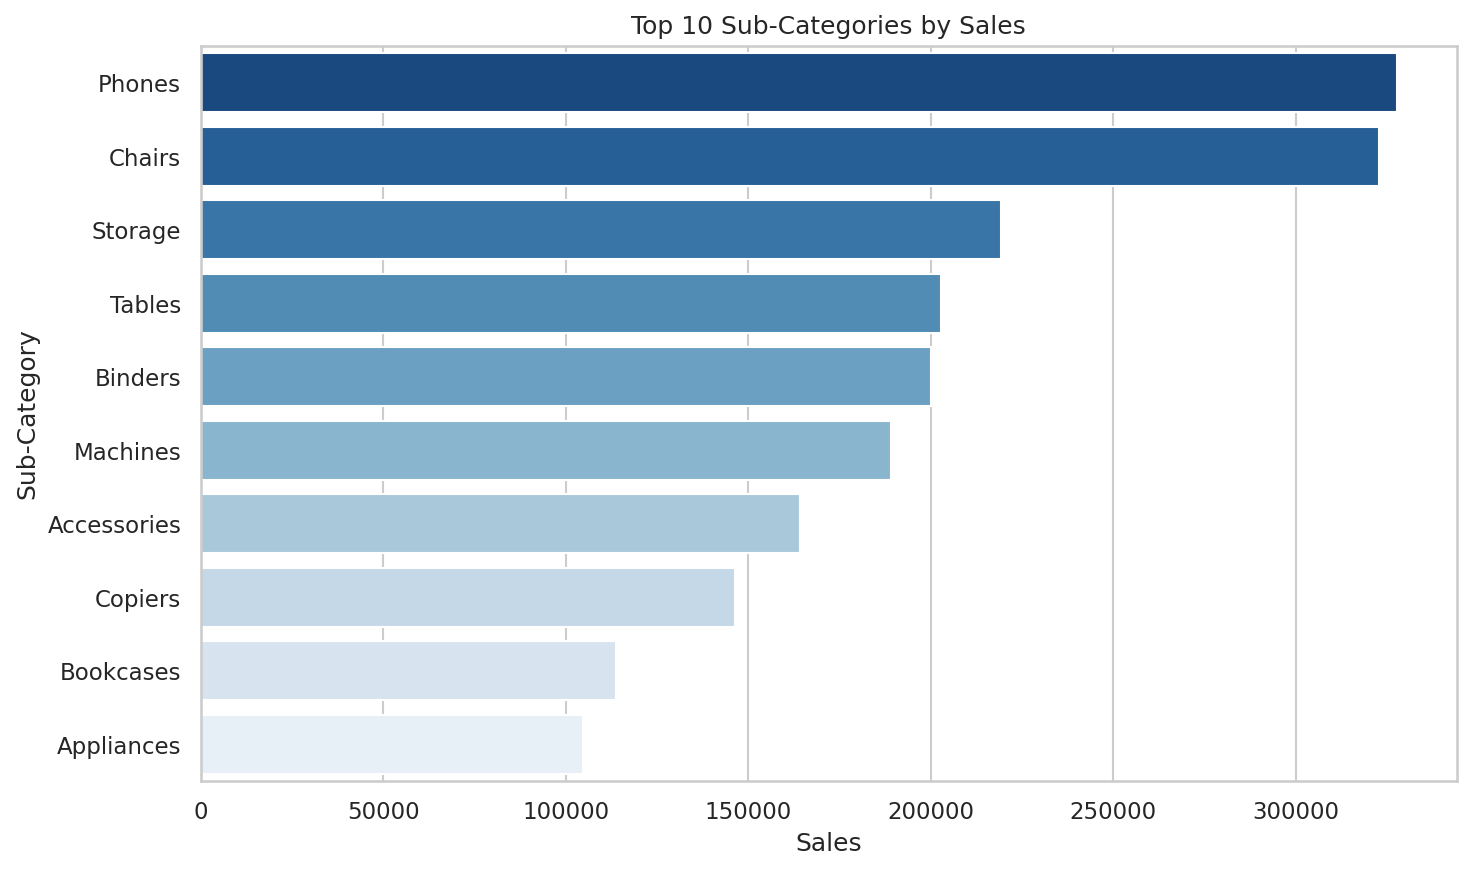


Cluster profile figure


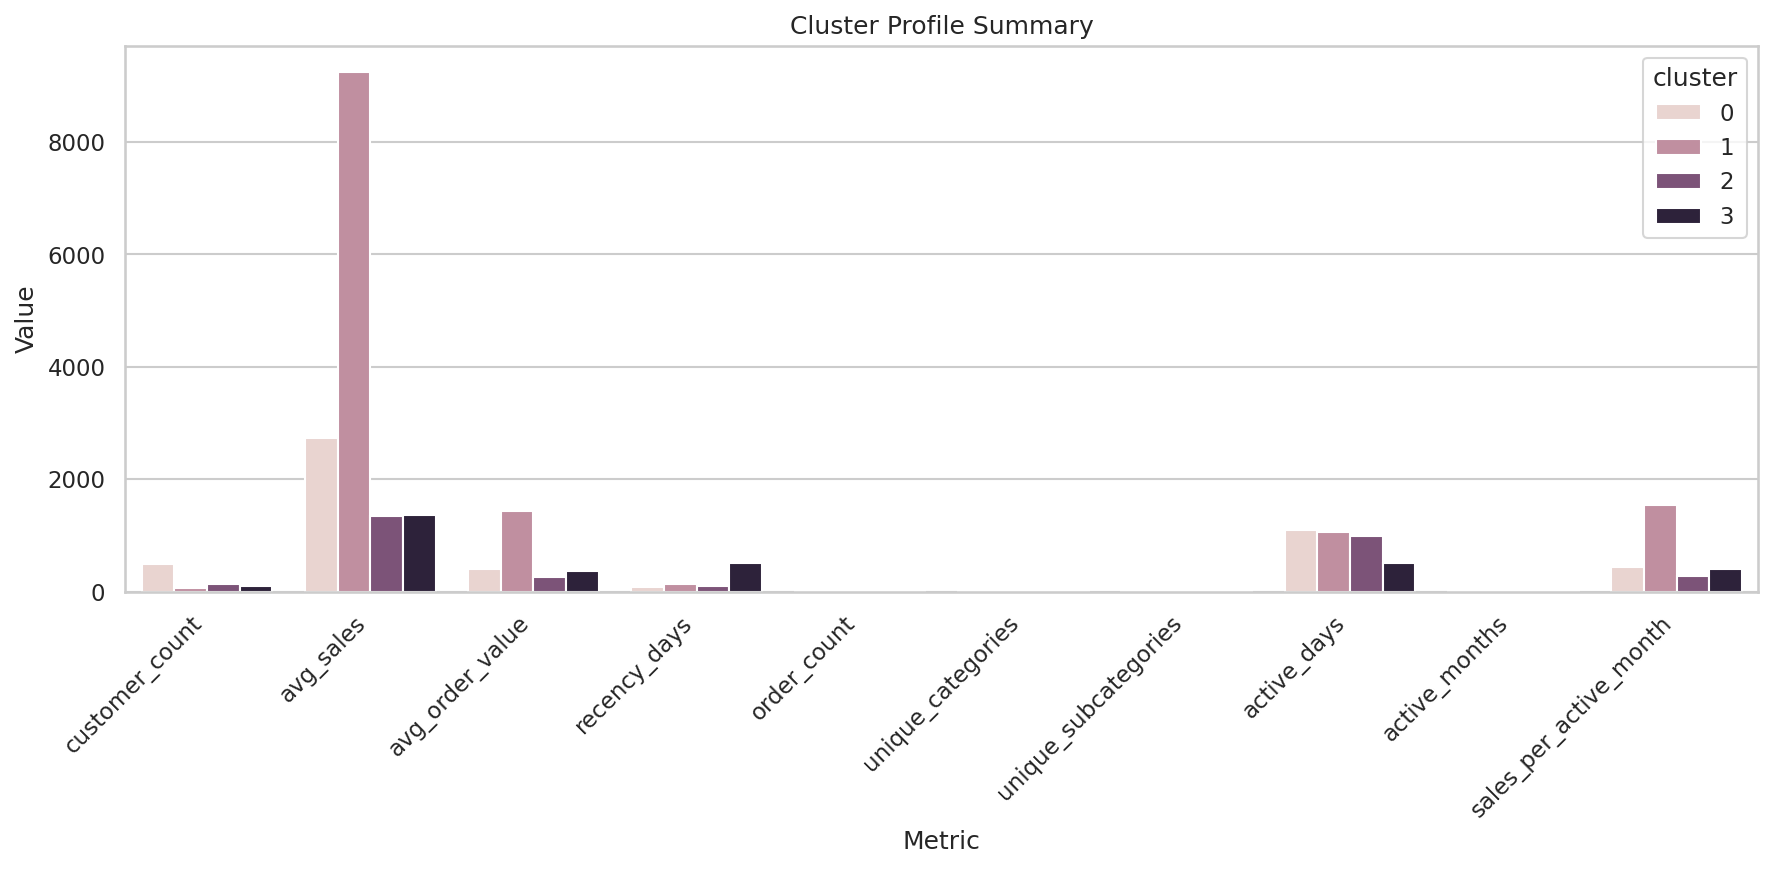

In [4]:
figures_dir = PROJECT_ROOT / 'outputs' / 'figures'
for title, filename in [
    ('Association sales overview', 'top_subcategories.png'),
    ('Cluster profile figure', 'cluster_profile.png'),
]:
    path = figures_dir / filename
    print(f'\n{title}')
    if path.exists():
        display(Image(filename=str(path)))
    else:
        print(f'Missing figure: {path}')
